## We are going 3D


In [5]:
from image_processing import *
import cv2
import numpy as np

# Load and convert images to grayscale if not already
img1 = cv2.imread('../34759_final_project_rect/seq_01/image_02/data/000000.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('../34759_final_project_rect/seq_01/image_03/data/000000.png', cv2.IMREAD_GRAYSCALE)
# Load the color image and apply the mask to get colors for valid points
color_img = cv2.cvtColor(cv2.imread('../34759_final_project_rect/seq_01/image_02/data/000000.png'), cv2.COLOR_BGR2RGB)

In [6]:
# Load calibration file and parse it
calibration = parse_calibration_data("../34759_final_project_rect/calib_cam_to_cam.txt")

In [7]:
P_left = calibration["P_rect_02"]
P_right = calibration["P_rect_03"]

print(P_left)
print(P_right)

Q = calculate_q_matrix(P_left, P_right)
print(Q)

[[     707.05           0      604.08      45.758]
 [          0      707.05      180.51    -0.34542]
 [          0           0           1    0.004981]]
[[     707.05           0      604.08     -334.11]
 [          0      707.05      180.51      2.3307]
 [          0           0           1   0.0032012]]
[[          1           0           0     -604.08]
 [          0           1           0     -180.51]
 [          0           0           0      707.05]
 [          0           0      1.8673           0]]


In [8]:
from matplotlib import pyplot as plt
def plot_disparity_map(disp_map):
    """
    Plot the disparity map using Matplotlib.

    Parameters:
    - disp_map: Disparity map generated from compute_disparity_map function.
    """
    # Set the minimum and maximum disparity values for visualization
    plt.figure(figsize=(10, 7))
    plt.imshow(disp_map, cmap='plasma')
    plt.colorbar(label='Disparity Value')
    plt.title("Disparity Map")
    plt.xlabel("X-axis (pixels)")
    plt.ylabel("Y-axis (pixels)")
    plt.show()

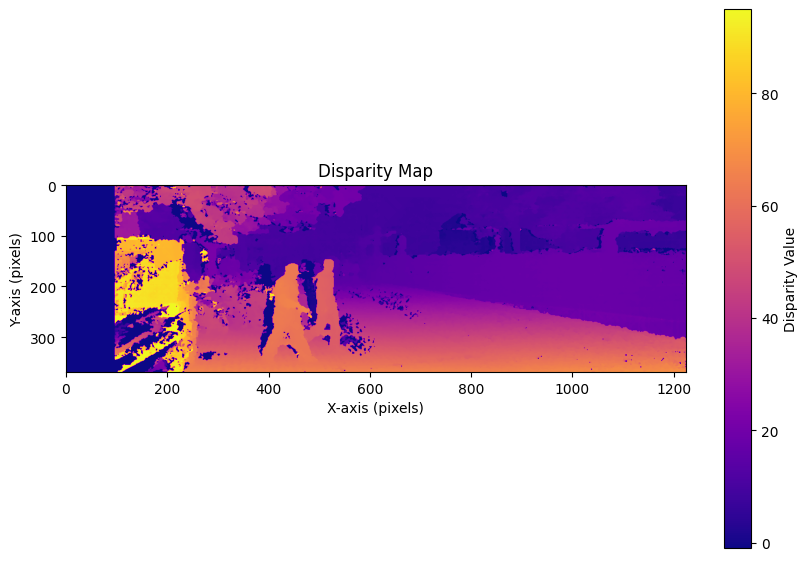

Disparity map range: -1.0 95.0


In [9]:
disp_map = compute_disparity_map(img1, img2,min_disparity=0, num_disparities=6*16, block_size=2)

plot_disparity_map(disp_map)

print(f'Disparity map range: {disp_map.min()} {disp_map.max()}')

In [14]:


points, colors = generate_point_cloud(disp_map, Q, color_image=color_img, max_z=20)


# Define your thresholds for x, y, and z axes
x_min, x_max = -10, 10    # Adjust these values as needed
y_min, y_max = -5, 5      # Adjust these values as needed
z_min, z_max = 0, 20      # Since you already have max_z=20, z_min can be set accordingly

# Create a boolean mask for points within the specified ranges
mask = (
    (points[:, 0] >= x_min) & (points[:, 0] <= x_max) &
    (points[:, 1] >= y_min) & (points[:, 1] <= y_max) &
    (points[:, 2] >= z_min) & (points[:, 2] <= z_max)
)

# Apply the mask to filter points and colors
filtered_points = points[mask]
filtered_colors = colors[mask]

# Optionally, update the 'points' and 'colors' variables if you wish to overwrite them
points = filtered_points
colors = filtered_colors

In [15]:


# Visualize
visualize_point_cloud(points, colors)



[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 


## 3D-point occlusion

In [13]:
from image_processing import *
import cv2

# Load and convert images to grayscale if not already
rect_img1 = cv2.imread('../34759_final_project_rect/seq_01/image_02/data/000000.png', cv2.IMREAD_GRAYSCALE)
rect_img2 = cv2.imread('../34759_final_project_rect/seq_01/image_03/data/000000.png', cv2.IMREAD_GRAYSCALE)
# Load the color image and apply the mask to get colors for valid points
color_img = cv2.cvtColor(cv2.imread('../34759_final_project_rect/seq_01/image_02/data/000000.png'), cv2.COLOR_BGR2RGB)

In [14]:
# Load calibration file and parse it
calibration = parse_calibration_data("../34759_final_project_rect/calib_cam_to_cam.txt")
P_left = calibration["P_rect_02"]
P_right = calibration["P_rect_03"]

In [15]:
bb_path = r"../bb_000000.txt"
bounding_boxes_dict = extract_bbox_from_txt(bb_path)
bounding_boxes = bounding_boxes_dict["bbox"]
bbox_mask = create_bbox_mask(rect_img1.shape, bounding_boxes)

In [16]:
point_cloud = RectImg2PC(rect_img1, rect_img2, P_left, P_right, color_img=color_img, mask=bbox_mask)

In [17]:
o3d.visualization.draw_geometries([point_cloud])
o3d.io.write_point_cloud('filtered_point_cloud.ply', point_cloud)

TypeError: draw_geometries(): incompatible function arguments. The following argument types are supported:
    1. (geometry_list: List[open3d.cpu.pybind.geometry.Geometry], window_name: str = 'Open3D', width: int = 1920, height: int = 1080, left: int = 50, top: int = 50, point_show_normal: bool = False, mesh_show_wireframe: bool = False, mesh_show_back_face: bool = False) -> None
    2. (geometry_list: List[open3d.cpu.pybind.geometry.Geometry], window_name: str = 'Open3D', width: int = 1920, height: int = 1080, left: int = 50, top: int = 50, point_show_normal: bool = False, mesh_show_wireframe: bool = False, mesh_show_back_face: bool = False, lookat: numpy.ndarray[numpy.float64[3, 1]], up: numpy.ndarray[numpy.float64[3, 1]], front: numpy.ndarray[numpy.float64[3, 1]], zoom: float) -> None

Invoked with: [(array([[    0.77482,       0.271,      6.0816],
       [    0.76622,       0.271,      6.0816],
       [    0.75676,     0.27069,      6.0747],
       ...,
       [      0.839,     -1.

# Same but segmentation instead of Bbox

In [18]:
from image_processing import *
import cv2

# Load and convert images to grayscale if not already
rect_img1 = cv2.imread('../34759_final_project_rect/seq_01/image_02/data/000000.png', cv2.IMREAD_GRAYSCALE)
rect_img2 = cv2.imread('../34759_final_project_rect/seq_01/image_03/data/000000.png', cv2.IMREAD_GRAYSCALE)
# Load the color image and apply the mask to get colors for valid points
color_img = cv2.cvtColor(cv2.imread('../34759_final_project_rect/seq_01/image_02/data/000000.png'), cv2.COLOR_BGR2RGB)


In [19]:
# Load calibration file and parse it
calibration = parse_calibration_data("../34759_final_project_rect/calib_cam_to_cam.txt")
P_left = calibration["P_rect_02"]
P_right = calibration["P_rect_03"]

In [20]:
seg_path = r"../points.json"
seg_mask = create_seg_mask(file_path=seg_path, image_shape=rect_img1.shape, target_class_labels=None)


In [21]:
point_cloud = RectImg2PC(rect_img1, rect_img2, P_left, P_right, max_z=20, color_img=color_img, mask=seg_mask)

In [22]:
o3d.visualization.draw_geometries([point_cloud])
o3d.io.write_point_cloud('filtered_point_cloud.ply', point_cloud)

TypeError: draw_geometries(): incompatible function arguments. The following argument types are supported:
    1. (geometry_list: List[open3d.cpu.pybind.geometry.Geometry], window_name: str = 'Open3D', width: int = 1920, height: int = 1080, left: int = 50, top: int = 50, point_show_normal: bool = False, mesh_show_wireframe: bool = False, mesh_show_back_face: bool = False) -> None
    2. (geometry_list: List[open3d.cpu.pybind.geometry.Geometry], window_name: str = 'Open3D', width: int = 1920, height: int = 1080, left: int = 50, top: int = 50, point_show_normal: bool = False, mesh_show_wireframe: bool = False, mesh_show_back_face: bool = False, lookat: numpy.ndarray[numpy.float64[3, 1]], up: numpy.ndarray[numpy.float64[3, 1]], front: numpy.ndarray[numpy.float64[3, 1]], zoom: float) -> None

Invoked with: [(array([[    0.77482,       0.271,      6.0816],
       [    0.76622,       0.271,      6.0816],
       [    0.75676,     0.27069,      6.0747],
       ...,
       [    0.96191,      -1

# Hungarian algorithm


In [1]:
from tracking import *
from image_processing import *
from ultralytics import YOLO
from pointcloud_clustering import *
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load and convert images to grayscale if not already
img_left1 = r'../34759_final_project_rect/seq_01/image_02/data/000000.png'
img_left2 = r'../34759_final_project_rect/seq_01/image_02/data/000001.png'
model = YOLO(r"../yolo11x-seg.pt")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
prev_detections = cluster_from_stereo(model=model, img_left=img_left1, save_results=True, visualize = True)


image 1/1 c:\Users\gtoft\OneDrive\Skrivebord\DTU\3_Semester_AS\Perception_for_AS\FinalProject\Perception-for-Autonomous-systems-DTU-2024\..\34759_final_project_rect\seq_01\image_02\data\000000.png: 224x640 2 persons, 407.0ms
Speed: 2.0ms preprocess, 407.0ms inference, 2.0ms postprocess per image at shape (1, 3, 224, 640)
Detection 0: X max=499, Y max=353
Detection 1: X max=553, Y max=330
Point cloud saved to c:\Users\gtoft\OneDrive\Skrivebord\DTU\3_Semester_AS\Perception_for_AS\FinalProject\results\000000_segmented_point_cloud.ply
Best parameters: eps=0.3, min_samples=1000
Centroid 0: Position=[     1.2666    -0.62547      5.3264], Class=0
Centroid 1: Position=[    0.78346    -0.54836      6.1065], Class=0


In [3]:
curr_detections = cluster_from_stereo(model=model, img_left=img_left2, save_results=True, visualize = True)


image 1/1 c:\Users\gtoft\OneDrive\Skrivebord\DTU\3_Semester_AS\Perception_for_AS\FinalProject\Perception-for-Autonomous-systems-DTU-2024\..\34759_final_project_rect\seq_01\image_02\data\000001.png: 224x640 2 persons, 883.1ms
Speed: 3.0ms preprocess, 883.1ms inference, 4.0ms postprocess per image at shape (1, 3, 224, 640)
Detection 0: X max=493, Y max=363
Detection 1: X max=549, Y max=330
Point cloud saved to c:\Users\gtoft\OneDrive\Skrivebord\DTU\3_Semester_AS\Perception_for_AS\FinalProject\results\000001_segmented_point_cloud.ply
Best parameters: eps=0.3, min_samples=1000
Centroid 0: Position=[     0.6988    -0.53836      6.0668], Class=0
Centroid 1: Position=[     1.1422    -0.61671      5.2826], Class=0


In [4]:
matches, unmatched_previous, unmatched_current = assign_centroids(prev_detections, curr_detections)

In [5]:
def visualize_assignments(previous_detections, current_detections, matches):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Plot previous detections
    prev_centroids = np.array([det.centroid for det in previous_detections])
    ax.scatter(prev_centroids[:, 0], prev_centroids[:, 1], prev_centroids[:, 2],
               c='r', label='Previous Detections')

    # Plot current detections
    curr_centroids = np.array([det.centroid for det in current_detections])
    ax.scatter(curr_centroids[:, 0], curr_centroids[:, 1], curr_centroids[:, 2],
               c='b', label='Current Detections')

    # Draw lines between matched detections
    for prev_idx, curr_idx in matches:
        x_values = [previous_detections[prev_idx].centroid[0],
                    current_detections[curr_idx].centroid[0]]
        y_values = [previous_detections[prev_idx].centroid[1],
                    current_detections[curr_idx].centroid[1]]
        z_values = [previous_detections[prev_idx].centroid[2],
                    current_detections[curr_idx].centroid[2]]
        ax.plot(x_values, y_values, z_values, c='g')

    ax.legend()
    plt.show()

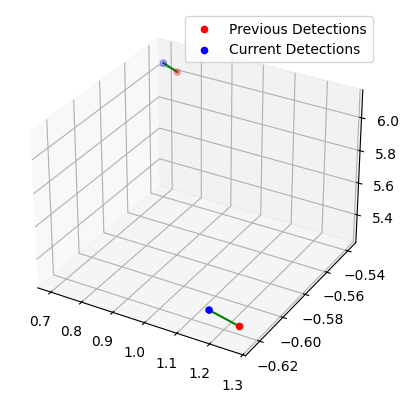

In [6]:
# After assigning centroids, call the visualization function
visualize_assignments(prev_detections, curr_detections, matches)

# Hungarian full run

In [1]:
from tracking import *
from image_processing import *
from ultralytics import YOLO
from pointcloud_clustering import *
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
def visualize_tracked_objects_histories(tracked_objects):
    """
    Visualize the trajectories of all tracked objects in 3D space after the run.

    Parameters:
    - tracked_objects: A list of TrackedObject instances.
    """
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D

    # Define colors for different classes
    class_colors = {
        0: 'red',       # Class label 0: red
        1: 'green',     # Class label 1: green
        2: 'blue',      # Class label 2: blue
    }

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the history of each tracked object
    for obj in tracked_objects:
        history = np.array(obj.history)
        if history.size == 0:
            continue  # Skip if there's no history
        color = class_colors.get(obj.class_label, 'black')  # Default to black if class not specified
        ax.plot(history[:, 0], history[:, 1], history[:, 2], color=color, label=f'Object {obj.id}')
        # Optionally, mark the starting and ending positions
        ax.scatter(history[0, 0], history[0, 1], history[0, 2], color=color, marker='o', s=50)
        ax.scatter(history[-1, 0], history[-1, 1], history[-1, 2], color=color, marker='X', s=50)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('Trajectories of Tracked Objects')

    # Avoid duplicate labels in the legend
    handles, labels = ax.get_legend_handles_labels()
    unique_labels = dict(zip(labels, handles))
    ax.legend(unique_labels.values(), unique_labels.keys())

    plt.show()


In [7]:
# Load and convert images to grayscale if not already
img_left1 = r'../34759_final_project_rect/seq_01/image_02/data/000000.png'
img_left2 = r'../34759_final_project_rect/seq_01/image_02/data/000001.png'
img_left3 = r'../34759_final_project_rect/seq_01/image_02/data/000002.png'
img_left4 = r'../34759_final_project_rect/seq_01/image_02/data/000003.png'
img_left5 = r'../34759_final_project_rect/seq_01/image_02/data/000004.png'
model = YOLO(r"../yolo11x-seg.pt")
video_frames = [img_left1,img_left2, img_left3, img_left4, img_left5]


Processing frame 1/5

image 1/1 c:\Users\gtoft\OneDrive\Skrivebord\DTU\3_Semester_AS\Perception_for_AS\FinalProject\Perception-for-Autonomous-systems-DTU-2024\..\34759_final_project_rect\seq_01\image_02\data\000000.png: 224x640 2 persons, 420.4ms
Speed: 2.0ms preprocess, 420.4ms inference, 1.0ms postprocess per image at shape (1, 3, 224, 640)
Left image path: ..\34759_final_project_rect\seq_01\image_02\data\000000.png
Right image path: ..\34759_final_project_rect\seq_01\image_03\data\000000.png
Detection 0: X max=499, Y max=353
Detection 1: X max=553, Y max=330
Best parameters: eps=0.2, min_samples=75
Centroid 0: Position=[    -1.4344     0.51714      5.9981], Class=0
Centroid 1: Position=[   -0.90174     0.41459       6.893], Class=0
Number of current detections: 2
Matches: []
Unmatched previous detections: []
Unmatched current detections: [0, 1]

Processing frame 2/5

image 1/1 c:\Users\gtoft\OneDrive\Skrivebord\DTU\3_Semester_AS\Perception_for_AS\FinalProject\Perception-for-Autonom

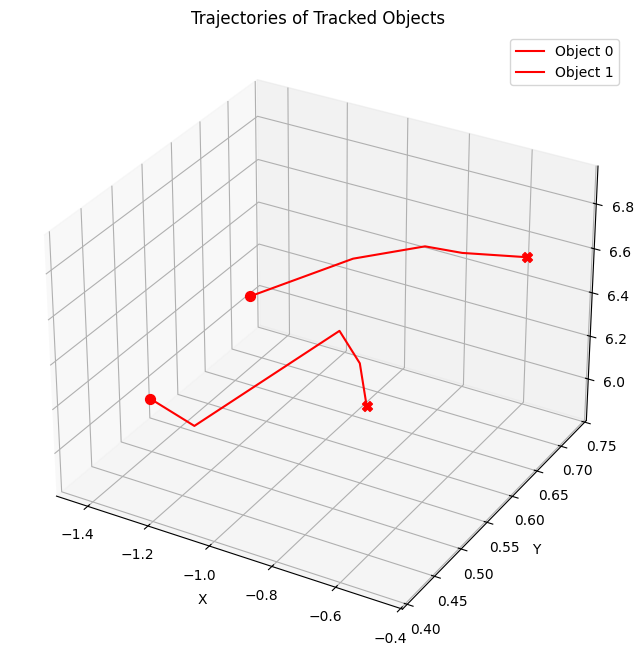

In [8]:
# Parameters
cost_threshold = 50
class_mismatch_penalty = 1000
max_age = 5

# Main tracking loop
tracked_objects = []
all_tracked_objects = []
next_object_id = 0

for frame_idx, frame in enumerate(video_frames):
    print(f"\nProcessing frame {frame_idx + 1}/{len(video_frames)}")
    
    # Get current detections
    current_detections = cluster_from_stereo(model, frame, conf= 0.7, save_results= False, visualize = False)
    print(f"Number of current detections: {len(current_detections)}")
    
    # Predict tracked object positions
    for obj in tracked_objects:
        obj.predict()
    
    # Assign detections to tracked objects
    previous_detections = [Detection(obj.centroid, obj.class_label) for obj in tracked_objects]
    
    matches, unmatched_prev, unmatched_curr = assign_centroids(
        previous_detections,
        current_detections,
        cost_threshold=cost_threshold,
        class_mismatch_penalty=class_mismatch_penalty
    )
    
    print(f"Matches: {matches}")
    print(f"Unmatched previous detections: {unmatched_prev}")
    print(f"Unmatched current detections: {unmatched_curr}")
    
    # Update matched tracked objects
    for prev_idx, curr_idx in matches:
        tracked_objects[prev_idx].update(current_detections[curr_idx])
    
    # Increase time_since_update for unmatched previous objects
    for idx in unmatched_prev:
        tracked_objects[idx].time_since_update += 1
    
    # Create new tracked objects for unmatched current detections
    for idx in unmatched_curr:
        obj = TrackedObject(current_detections[idx], next_object_id)
        tracked_objects.append(obj)
        next_object_id += 1
    
    # Remove lost tracked objects
    lost_objects = [obj for obj in tracked_objects if obj.time_since_update > max_age]
    tracked_objects = [obj for obj in tracked_objects if obj.time_since_update <= max_age]
    all_tracked_objects.extend(lost_objects)

# After the loop, add remaining tracked objects
all_tracked_objects.extend(tracked_objects)

# Visualize after the run
visualize_tracked_objects_histories(all_tracked_objects)



In [14]:
# After the loop, visualize the tracked object histories
visualize_tracked_objects_histories(all_tracked_objects)


<IPython.core.display.Javascript object>

# labels file

In [1]:
from labelextract import *
labels_path = r"../34759_final_project_rect/seq_01/labels.txt"
labels_dict = parse_label_file(labels_path)

In [ ]:
locations = filter_and_extract_locations(labels_dict, frame=0, track_id=[0,1], obj_type=None)
print(locations)

[[-0.875495  1.374252  6.816363]
 [-1.333895  1.397117  5.92395 ]]
